# Spotify Tracks Analysis — 02 Analysis

What do audio features look like, and — the real question — do they predict popularity?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()
print('tracks',len(df),'genres',df.track_genre.nunique())

tracks 114000 genres 114


## 1. Audio-feature distributions

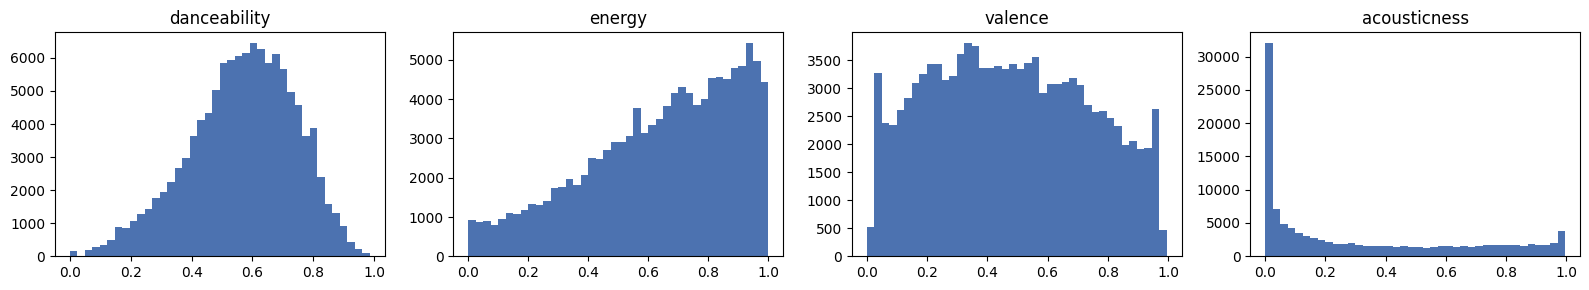

In [2]:
feats=['danceability','energy','valence','acousticness']
fig,ax=plt.subplots(1,4,figsize=(16,3))
for a,f in zip(ax,feats): a.hist(df[f],bins=40,color='#4c72b0'); a.set_title(f)
plt.tight_layout(); plt.show()

## 2. Most popular genres

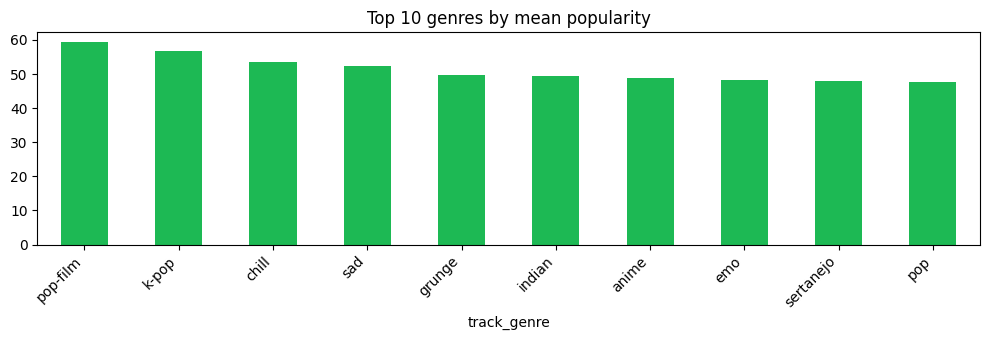

{'pop-film': 59.3, 'k-pop': 56.9, 'chill': 53.7, 'sad': 52.4, 'grunge': 49.6, 'indian': 49.5, 'anime': 48.8, 'emo': 48.1, 'sertanejo': 47.9, 'pop': 47.6}


In [3]:
g=df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(10,3.5)); g.plot(kind='bar',ax=ax,color='#1DB954'); ax.set_title('Top 10 genres by mean popularity'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(g.round(1).to_dict())

## 3. Do audio features predict popularity?

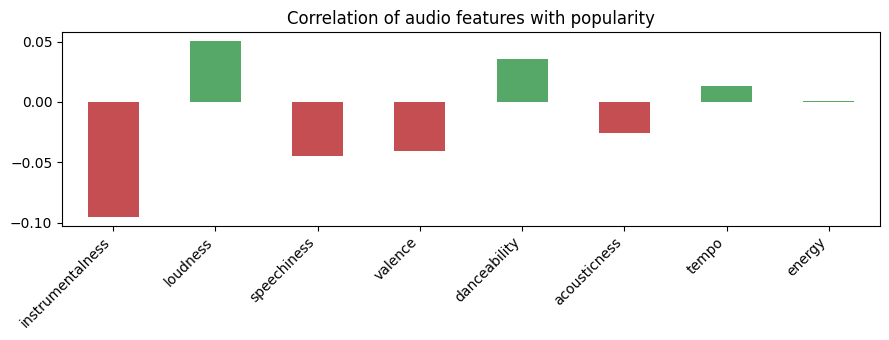

instrumentalness   -0.095
loudness            0.050
speechiness        -0.045
valence            -0.041
danceability        0.035
acousticness       -0.025
tempo               0.013
energy              0.001


In [4]:
af=['danceability','energy','valence','acousticness','instrumentalness','loudness','tempo','speechiness']
cor=df[['popularity']+af].corr()['popularity'].drop('popularity').sort_values(key=abs,ascending=False)
fig,ax=plt.subplots(figsize=(9,3.5)); cor.plot(kind='bar',ax=ax,color=np.where(cor<0,'#c44e52','#55a868')); ax.set_title('Correlation of audio features with popularity'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(cor.round(3).to_string())

## 4. Feature correlation heatmap

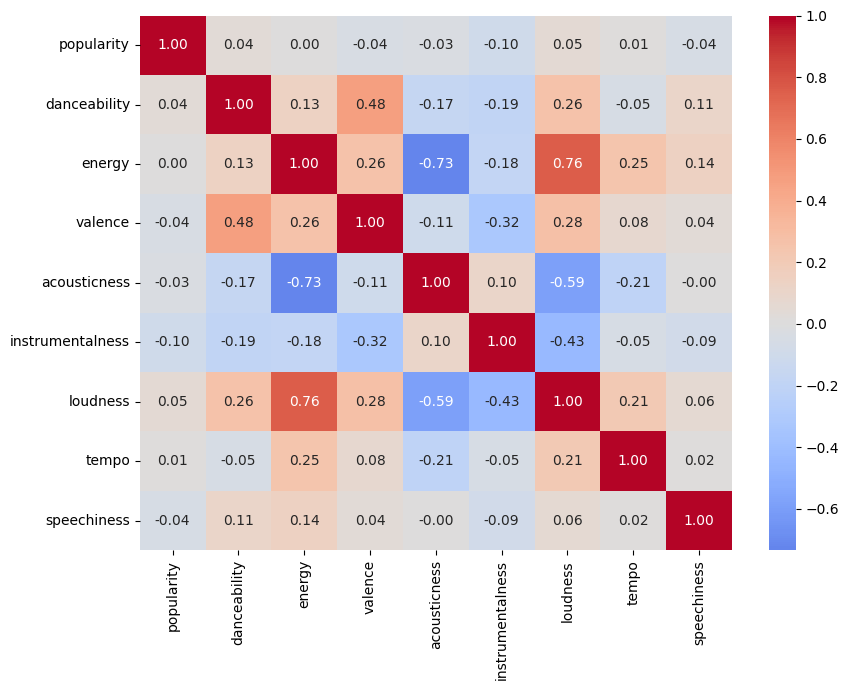

In [5]:
fig,ax=plt.subplots(figsize=(9,7)); sns.heatmap(df[['popularity']+af].corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0,ax=ax); plt.tight_layout(); plt.show()

## 5. Key findings

- **114,000 tracks across 114 genres**; only **8.6% are explicit**.
- **Energy and danceability skew high; acousticness is bimodal** (tracks are either acoustic or not).
- **Most popular genres**: pop-film, k-pop, chill, sad, grunge (by mean popularity).
- **The headline honest result: audio features barely predict popularity** — the strongest correlation is loudness at just **0.05** (|r| ≤ 0.05 for every feature). Popularity is driven by artist, marketing, and playlisting, *not* by how the audio sounds.
- Strong feature *inter*-correlations exist (energy↔loudness, energy↔acousticness negative) — but none of that reaches the listener-popularity outcome.